# Modelling clothing shop reviews

In this notebook first we will split the data, then create pipelines for num, cat and text data. After that we will merge this pipelines and use ML models for predictions. At the end we will also fine tune our model.

## Libraries import and data preparation

In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import spacy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import FeatureUnion
from tqdm import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

nlp = spacy.load('en_core_web_sm')

In [32]:
data = pd.read_csv("reviews.csv")
num_cols = ["Age", "Positive Feedback Count"]
cat_cols = ["Division Name", "Department Name", "Class Name"]
text_cols = ["Review Text"]
data = data.drop(["Clothing ID"], axis=1)

X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=42)

## Preparing Pipelines


### Numerical Features Pipeline

In [20]:
num_pipeline = Pipeline([
    (
        'scaler',
        StandardScaler(),
    ),
])

num_pipeline

Pipeline(steps=[('scaler', StandardScaler())])

### Categorical Features Pipeline

In [33]:
cat_pipeline = Pipeline([
    (
        'ordinal_encoder',
        OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )
    ),
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        )
    ),
])
cat_pipeline

Pipeline(steps=[('ordinal_encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('cat_encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

### Text Feature Pipeline

#### Word Count Transformer
In the text pipeline we will create two custom features. First one will count good and bad words already chosen like good, perfect or bad.

In [44]:
class WordCount(BaseEstimator, TransformerMixin):
    def __init__(self, words: np.array):
        self.words = words
        return

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        counts = []
        for text_sample in X:
            current_count = 0
            for word in str(text_sample).split(" "):
                if word in self.words:
                    current_count += 1
            counts.append(current_count)
        return np.atleast_2d(np.array(counts).reshape(-1, 1))



In [45]:
positive_words = np.array(['good','perfect','awesome', 'love'])
negative_words = np.array(['hate', 'bad','badly','disappointed'])

initial_text_preprocess = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
])

feature_engineering = FeatureUnion([
    ('positive_words_count', WordCount(words = positive_words)),
    ('negative_words_count', WordCount(words = negative_words)),
])

character_counts_pipeline = Pipeline([
    (
        'initial_text_preprocess',
        initial_text_preprocess,
    ),
    (
        'feature_engineering',
        feature_engineering,
    ),
])

character_counts_pipeline

Pipeline(steps=[('initial_text_preprocess',
                 Pipeline(steps=[('dimension_reshaper',
                                  FunctionTransformer(func=<function reshape at 0x7aef45f66cf0>,
                                                      kw_args={'newshape': -1}))])),
                ('feature_engineering',
                 FeatureUnion(transformer_list=[('positive_words_count',
                                                 WordCount(words=array(['good', 'perfect', 'awesome', 'love'], dtype='<U7'))),
                                                ('negative_words_count',
                                                 WordCount(words=array(['hate', 'bad', 'badly', 'disappointed'], dtype='<U12')))]))])

#### Sentiment Analysis Transformer

Now when we have one pipeline for word counts, let's create the second one that will analyze the sentiment and help getting better context of reviews. We have bigger data set, so we will optimize a little bit process of transforming. First, instead of bert-base model we will use tiny bert, which has lesser parameters, but for our task will do fine. Second, we will transform our data in batches of size 32, not to create massive matrix. Last, but not least we will use cuda for GPU computing, which will be much faster solution. To do it, I will use Google Colab environment for compiling our code, where there is GPU T4 available.

In [28]:
class Sentiment(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='huawei-noah/TinyBERT_General_4L_312D', batch_size=32):
        self.model_name = model_name
        self.batch_size = batch_size
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        self.model.eval()
        all_embeddings = []

        # batch processing
        for i in tqdm(range(0, len(X), self.batch_size)):
            batch_texts = X[i : i + self.batch_size]
            batch_texts = batch_texts.tolist() if hasattr(batch_texts, 'tolist') else batch_texts

            inputs = self.tokenizer(batch_texts, return_tensors='pt',
                                    padding=True, truncation=True, max_length=128).to(self.device)

            with torch.no_grad():
                outputs = self.model(**inputs)
                embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                all_embeddings.append(embeddings)

        return np.vstack(all_embeddings)

In [29]:
sentiment_pipeline = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
    (
        'sentiment_analyzer',
        Sentiment(),
    ),
])
sentiment_pipeline

Pipeline(steps=[('dimension_reshaper',
                 FunctionTransformer(func=<function reshape at 0x7aef45f66cf0>,
                                     kw_args={'newshape': -1})),
                ('sentiment_analyzer', Sentiment())])

## Combine Pipelines

Now, we will combine all the pipelines we created above.

In [46]:
feature_engineering = ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
        ('character_counts', character_counts_pipeline, text_cols),
        ('sentiment_analysis', sentiment_pipeline, text_cols),
])

feature_engineering

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age', 'Positive Feedback Count']),
                                ('cat',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1)),
                                                 ('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Division Name', 'Department Name',
                                  'Class Name'...
                                                                                  WordCount(words=array(['good', 'perfect', 'awesome', 'love'], dtype='<U7'))),
                                                                                 ('negative_words_count',
                                                                                  WordCount(words=array(['hate', 'bad', 'badly', 'disappointed'], dtype='<U12')))]))]),
                                 ['Review Text']),
                                ('sentiment_analysis',
                                 Pipeline(steps=[('dimension_reshaper',
                                                  FunctionTransformer(func=<function reshape at 0x7aef45f66cf0>,
                                                                      kw_args={'newshape': -1})),
                                                 ('sentiment_analyzer',
                                                  Sentiment())]),
                                 ['Review Text'])])

## Model training and evaluation

In this section, we will train Random Forest Classifier.

In [47]:
model_pipeline = make_pipeline(
    feature_engineering,
    RandomForestClassifier(random_state=27),
)

model_pipeline.fit(X_train, y_train)

100%|██████████| 519/519 [00:12<00:00, 40.69it/s]


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  Pipeline(steps=[('ordinal_encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('cat_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Divis...
                                                                                                   WordCount(words=array(['hate', 'bad', 'badly', 'disappointed'], dtype='<U12')))]))]),
                                                  ['Review Text']),
                                                 ('sentiment_analysis',
                                                  Pipeline(steps=[('dimension_reshaper',
                                                                   FunctionTransformer(func=<function reshape at 0x7aef45f66cf0>,
                                                                                       kw_args={'newshape': -1})),
                                                                  ('sentiment_analyzer',
                                                                   Sentiment())]),
                                                  ['Review Text'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=27))])

In [50]:
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', accuracy)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
100%|██████████| 58/58 [00:01<00:00, 40.02it/s]

Accuracy: 0.8639566395663957


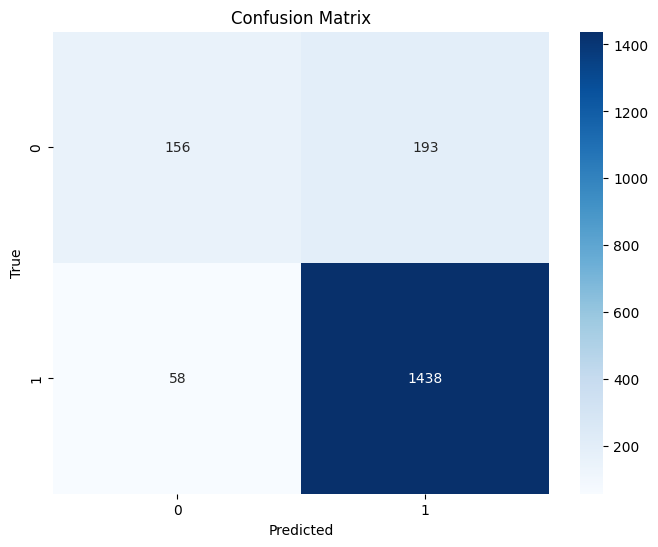

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

We got decent 0.86 accuracy score. But this can be misleading. On confusion matrix we can see that we don't predict bad reviews right. This is because imbalanced data set.

## Hyper-parameter tuning

We will use Grid Search for finding best parameters. Also, we will use cross-validation for better evaluating the results.

Finally, we will train model on best parameters and evaluate final score.